# 🫁 CXR DenseNet121 — **v1 LIGERO** (CPU · modelo independiente)
## TFM · Módulo de Imagen (Radiografía de tórax) · Universidad de Salamanca

---

## 🎯 Qué es esta versión (la más ligera de las 3)

Las 6 etiquetas son **hallazgos radiográficos** (CheXpert), así que el backbone **DenseNet121** preentrenado en
radiografías (`densenet121-res224-all`, *CheXNet*) ya separa muy bien. La estrategia que mejor funciona en CPU es:
**backbone congelado → embeddings (una sola pasada) → cabeza ligera encima**.

| Las 3 versiones | Cabeza | Coste CPU |
|---|---|---|
| **v1 (esta, ligera)** | **Regresión logística** one-vs-rest sobre los embeddings | **minutos** (reutiliza embeddings) |
| v2 (óptima) | MLP + metadatos + correlación de etiquetas + K-fold | ~1–2 h |
| v3 (pesada) | Ensemble de 2 backbones (DenseNet121 + ResNet50@512) + TTA + bagging | varias horas (<24 h) |

## ♻️ Reutiliza los embeddings del v2
El único paso caro (pasar 11k imágenes por el backbone) **ya está hecho y cacheado** en
`outputs_cxr_densenet121_v2/embeddings/`. Esta versión los carga y entrena la cabeza en segundos. Si no existen,
ejecuta primero el **01_CXR v2** (o el v3), que los generan.

## 🛡️ Se mantienen TODAS las reglas del proyecto
- **Masking** de NaN (excluido del ajuste) y de −1 (según `uncertainty_policy`).
- **Negativos derivados por exclusividad de *No Finding*** (si No Finding=1 → patologías=0; si hay patología → No Finding=0).
- **Desequilibrio** por etiqueta (`class_weight="balanced"`), **calibración isotónica** y **OOF sin fuga** para el stacking.


In [1]:
# CELDA 1 · DEPENDENCIAS
import subprocess, sys
for p in ["scikit-learn","pandas","numpy","matplotlib","seaborn"]:
    subprocess.run([sys.executable,"-m","pip","install",p,"-q"], check=False)
print("Dependencias listas.")

Dependencias listas.


In [2]:
# CELDA 2 · IMPORTS, RUTAS Y CONSTANTES
import json, warnings
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score,
                             confusion_matrix, roc_curve, precision_recall_curve)
warnings.filterwarnings("ignore"); SEED=42; np.random.seed(SEED)

BASE=Path(r"C:\TFM\1.Opción - Symile Mimic\symile-mimic-a-multimodal-clinical-dataset-of-chest-x-rays-electrocardiograms-and-blood-labs-from-mimic-iv-1.0.0")
CSV=BASE/"data_csv"/"clean"
TRAIN_CSV,VAL_CSV,TEST_CSV=CSV/"train_clean.csv",CSV/"val_clean.csv",CSV/"test_clean.csv"
EMB_SHARED=Path("outputs_cxr_densenet121_v2")/"embeddings"   # embeddings cacheados (backbone congelado)
OUTPUT_DIR=Path("outputs_cxr_densenet121_v1"); OUTPUT_DIR.mkdir(exist_ok=True)
FIG_DIR=OUTPUT_DIR/"figuras"; FIG_DIR.mkdir(exist_ok=True)

LABELS=["Atelectasis","Cardiomegaly","Edema","Lung Opacity","No Finding","Pleural Effusion"]
N_LABELS=len(LABELS); NO_FINDING="No Finding"
PATHOLOGY=[l for l in LABELS if l!=NO_FINDING]; CORE=["Cardiomegaly","Edema","Pleural Effusion"]
K_FOLDS=5; LOGREG_C=0.5
print("Salidas en", OUTPUT_DIR)

Salidas en outputs_cxr_densenet121_v1


In [3]:
# CELDA 3 · CARGA DE DATOS Y EMBEDDINGS CACHEADOS
df_train=pd.read_csv(TRAIN_CSV,sep=";"); df_val=pd.read_csv(VAL_CSV,sep=";"); df_test=pd.read_csv(TEST_CSV,sep=";")
need=[EMB_SHARED/f"emb_{s}.npy" for s in ["train","val","test"]]
if not all(p.exists() for p in need):
    raise FileNotFoundError("Faltan los embeddings cacheados en "+str(EMB_SHARED)+
                            ". Ejecuta primero el notebook 01_CXR_DenseNet121_v2 (o v3), que pasan el backbone y los guardan.")
emb_train=np.load(need[0]); emb_val=np.load(need[1]); emb_test=np.load(need[2])
assert len(emb_train)==len(df_train) and len(emb_val)==len(df_val) and len(emb_test)==len(df_test), \
       "Los embeddings no cuadran con los CSV (¿cambió el preprocesado? re-extrae con el v2)."
print(f"emb_train={emb_train.shape}  emb_val={emb_val.shape}  emb_test={emb_test.shape}")

emb_train=(10000, 1024)  emb_val=(750, 1024)  emb_test=(464, 1024)


In [4]:
# CELDA 4 · OBJETIVOS (masking de NaN/−1 + negativos derivados por exclusividad de 'No Finding')
def build_targets(df, uncertainty_policy="zeros", derive=True, verbose=False):
    raw=df[LABELS].to_numpy(dtype=float); N=raw.shape[0]
    labels=np.zeros((N,N_LABELS),np.float32); mask=np.zeros((N,N_LABELS),np.float32)
    mask[~np.isnan(raw)]=1.0                      # observado -> entra en el ajuste/evaluación
    labels[raw==1]=1.0                            # positivo explícito
    unc=(raw==-1); labels[unc]=1.0 if uncertainty_policy=="ones" else 0.0   # incertidumbre CheXpert
    nf=LABELS.index(NO_FINDING); pc=[j for j in range(N_LABELS) if j!=nf]; ndp=ndn=0
    if derive:                                    # exclusividad: SOLO rellena NaN, nunca pisa lo observado
        nfp=(raw[:,nf]==1)
        for j in pc:
            f=nfp&np.isnan(raw[:,j]); labels[f,j]=0.0; mask[f,j]=1.0; ndp+=int(f.sum())
        ap=(raw[:,pc]==1).any(1); fn=ap&np.isnan(raw[:,nf]); labels[fn,nf]=0.0; mask[fn,nf]=1.0; ndn=int(fn.sum())
    if verbose: print(f"   negativos derivados -> patologías={ndp:,} · No Finding={ndn:,}")
    return labels,mask
y_train,m_train=build_targets(df_train,verbose=True)
y_val,m_val=build_targets(df_val); y_test,m_test=build_targets(df_test)
print("Balance (train, observados):")
for j,l in enumerate(LABELS):
    s=m_train[:,j]==1; print(f"   {l:18s} pos={int((y_train[s,j]==1).sum()):5d}  neg={int((y_train[s,j]==0).sum()):5d}")

   negativos derivados -> patologías=6,091 · No Finding=7,691
Balance (train, observados):
   Atelectasis        pos= 2867  neg= 2052
   Cardiomegaly       pos= 3346  neg= 2495
   Edema              pos= 2067  neg= 3735
   Lung Opacity       pos= 3108  neg= 1733
   No Finding         pos= 1368  neg= 7691
   Pleural Effusion   pos= 3618  neg= 3194


In [5]:
# CELDA 5 · MÉTRICAS (AUC/AP/F1 con masking) + búsqueda de umbral por F1
def multilabel_metrics(probs,labels,mask,thresholds=None):
    if thresholds is None: thresholds={l:0.5 for l in LABELS}
    res={}
    for j,l in enumerate(LABELS):
        s=mask[:,j]==1; yt=labels[s,j]; yp=probs[s,j]; npos=int(yt.sum()); nneg=int((1-yt).sum())
        pred=(yp>=thresholds.get(l,0.5)).astype(float)
        auc=roc_auc_score(yt,yp) if npos>=2 and nneg>=2 else float("nan")
        ap=average_precision_score(yt,yp) if npos>=2 and nneg>=2 else float("nan")
        tp=int(((pred==1)&(yt==1)).sum()); tn=int(((pred==0)&(yt==0)).sum())
        fp=int(((pred==1)&(yt==0)).sum()); fn=int(((pred==0)&(yt==1)).sum())
        res[l]={"AUC":auc,"AP":ap,"F1":f1_score(yt,pred,zero_division=0),
                "sens":tp/max(tp+fn,1),"spec":tn/max(tn+fp,1),"n_pos":npos,"n_neg":nneg,
                "TP":tp,"TN":tn,"FP":fp,"FN":fn,"thr":thresholds.get(l,0.5)}
    mac=lambda g:float(np.nanmean([res[l]["AUC"] for l in g])) if any(not np.isnan(res[l]["AUC"]) for l in g) else float("nan")
    res["macro_AUC_core"]=mac(CORE); res["macro_AUC_path"]=mac(PATHOLOGY); return res
def best_thresholds_by_f1(probs,labels,mask):
    grid=np.linspace(0.05,0.95,37); thr={}
    for j,l in enumerate(LABELS):
        s=mask[:,j]==1; yt=labels[s,j]; yp=probs[s,j]
        if yt.sum()<2: thr[l]=0.5; continue
        bf,bt=-1,0.5
        for t in grid:
            f=f1_score(yt,(yp>=t).astype(float),zero_division=0)
            if f>bf: bf,bt=f,t
        thr[l]=float(bt)
    return thr
print("Métricas listas.")

Métricas listas.


In [6]:
# CELDA 6 · CABEZA LIGERA: LogReg one-vs-rest sobre embeddings (con masking + balanceo)
# Para cada etiqueta se entrena SOLO con las muestras observadas (mask==1); class_weight balancea el desequilibrio.
def fit_predict_ovr(Xtr, ytr, mtr, Xva):
    P=np.full((len(Xva),N_LABELS),0.5,np.float32)
    for j in range(N_LABELS):
        sel=mtr[:,j]==1; Xj=Xtr[sel]; yj=ytr[sel,j]
        if len(np.unique(yj))<2:                # etiqueta sin ambas clases -> probabilidad base
            P[:,j]=float(yj.mean()) if len(yj) else 0.5; continue
        clf=LogisticRegression(C=LOGREG_C,class_weight="balanced",max_iter=2000)
        clf.fit(Xj,yj); P[:,j]=clf.predict_proba(Xva)[:,1]
    return P
# Estandarizado de embeddings ajustado SOLO en train (sin fuga)
scaler=StandardScaler().fit(emb_train)
Xtr=scaler.transform(emb_train).astype(np.float32)
Xva=scaler.transform(emb_val).astype(np.float32)
Xte=scaler.transform(emb_test).astype(np.float32)
print("Cabeza LogReg lista.")

Cabeza LogReg lista.


In [7]:
# CELDA 7 · K-FOLD -> OOF de train (sin fuga) + predicción de val/test
# OOF: cada muestra de train la predice un modelo que NO la vio -> válido para entrenar el meta-modelo (stacking).
kf=KFold(K_FOLDS,shuffle=True,random_state=SEED)
oof_train=np.zeros((len(df_train),N_LABELS),np.float32); fold_macro=[]
for k,(tr,va) in enumerate(kf.split(np.arange(len(df_train)))):
    oof_train[va]=fit_predict_ovr(Xtr[tr],y_train[tr],m_train[tr],Xtr[va])
    mm=multilabel_metrics(oof_train[va],y_train[va],m_train[va]); fold_macro.append(mm["macro_AUC_path"])
    print(f"Fold {k+1}/{K_FOLDS}: macroAUC_path={mm['macro_AUC_path']:.4f}")
# Modelos finales sobre TODO el train -> val/test
val_pred_raw=fit_predict_ovr(Xtr,y_train,m_train,Xva)
test_pred_raw=fit_predict_ovr(Xtr,y_train,m_train,Xte)
print(f"\nOOF macroAUC_path={np.nanmean(fold_macro):.4f}±{np.nanstd(fold_macro):.4f}")

Fold 1/5: macroAUC_path=0.7396
Fold 2/5: macroAUC_path=0.7431
Fold 3/5: macroAUC_path=0.7285
Fold 4/5: macroAUC_path=0.7385
Fold 5/5: macroAUC_path=0.7298

OOF macroAUC_path=0.7359±0.0057


In [8]:
# CELDA 8 · CALIBRACIÓN ISOTÓNICA (ajustada en val) + umbrales por F1
calibrators={}
for j,l in enumerate(LABELS):
    s=m_val[:,j]==1; yt=y_val[s,j]; yp=val_pred_raw[s,j]
    calibrators[l]=None if len(np.unique(yt))<2 else IsotonicRegression(out_of_bounds="clip").fit(yp,yt)
def apply_cal(P):
    O=P.copy()
    for j,l in enumerate(LABELS):
        if calibrators[l] is not None: O[:,j]=calibrators[l].predict(P[:,j])
    return O
oof_cal=apply_cal(oof_train); val_pred=apply_cal(val_pred_raw); test_pred=apply_cal(test_pred_raw)
thr_val=best_thresholds_by_f1(val_pred,y_val,m_val)
print("Calibración isotónica aplicada a OOF/val/test · umbrales fijados en val.")

Calibración isotónica aplicada a OOF/val/test · umbrales fijados en val.


In [9]:
# CELDA 9 · EVALUACIÓN EN TEST + tabla por etiqueta
M=multilabel_metrics(test_pred,y_test,m_test,thresholds=thr_val); rows=[]
print(f"{'Etiqueta':18s} {'AUC':>7} {'AP':>7} {'F1':>7} {'Sens':>6} {'Spec':>6} {'N+':>5} {'N-':>5}"); print("-"*72)
for l in LABELS:
    m=M[l]; auc=f"{m['AUC']:.4f}" if not np.isnan(m['AUC']) else "  N/A"
    print(f"{l:18s} {auc:>7} {m['AP']:7.4f} {m['F1']:7.4f} {m['sens']:6.3f} {m['spec']:6.3f} {m['n_pos']:5d} {m['n_neg']:5d}")
    rows.append({"label":l,**{k:m[k] for k in ['AUC','AP','F1','sens','spec','n_pos','n_neg']}})
print("-"*72); print(f"MACRO core={M['macro_AUC_core']:.4f} · MACRO patol.={M['macro_AUC_path']:.4f}")
pd.DataFrame(rows).to_csv(OUTPUT_DIR/"metrics_per_label_v1.csv",index=False)
json.dump({"version":"CXR v1 ligero (LogReg sobre embeddings DenseNet121)","cv_macro_path":float(np.nanmean(fold_macro)),
           "test_macro_core":M["macro_AUC_core"],"test_macro_path":M["macro_AUC_path"],
           "test_per_label":{l:M[l] for l in LABELS}},
          open(OUTPUT_DIR/"summary_v1.json","w",encoding="utf-8"),indent=2,default=str,ensure_ascii=False)
print("Guardados metrics_per_label_v1.csv y summary_v1.json")

Etiqueta               AUC      AP      F1   Sens   Spec    N+    N-
------------------------------------------------------------------------
Atelectasis         0.6659  0.6875  0.7742  0.851  0.484   141    95
Cardiomegaly        0.6678  0.6357  0.7263  0.931  0.305   144   131
Edema               0.7998  0.6212  0.6256  0.805  0.654    82   182
Lung Opacity        0.6847  0.7006  0.7509  0.840  0.435   131    92
No Finding          0.6667  0.3695  0.3860  0.478  0.802    69   349
Pleural Effusion    0.8368  0.8223  0.7722  0.837  0.660   166   162
------------------------------------------------------------------------
MACRO core=0.7681 · MACRO patol.=0.7310
Guardados metrics_per_label_v1.csv y summary_v1.json


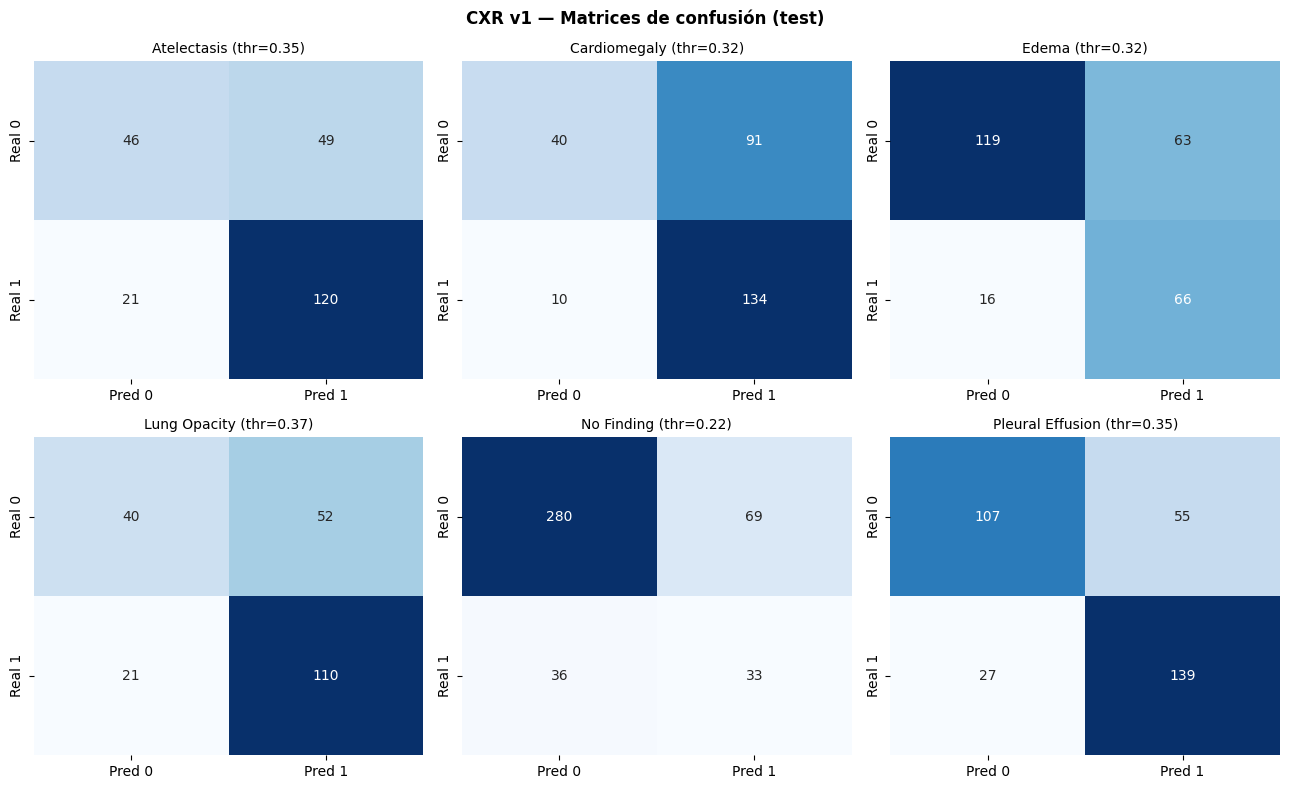

In [10]:
# CELDA 10 · MATRICES DE CONFUSIÓN (test)
fig,axes=plt.subplots(2,3,figsize=(13,8)); fig.suptitle("CXR v1 — Matrices de confusión (test)",fontweight="bold")
for j,l in enumerate(LABELS):
    ax=axes[j//3,j%3]; s=m_test[:,j]==1; yt=y_test[s,j]; yp=(test_pred[s,j]>=thr_val.get(l,0.5)).astype(int)
    if len(yt)==0: ax.axis("off"); continue
    sns.heatmap(confusion_matrix(yt,yp,labels=[0,1]),annot=True,fmt="d",cmap="Blues",cbar=False,ax=ax,
                xticklabels=["Pred 0","Pred 1"],yticklabels=["Real 0","Real 1"])
    ax.set_title(f"{l} (thr={thr_val.get(l,0.5):.2f})",fontsize=10)
plt.tight_layout(); plt.savefig(FIG_DIR/"confusion_v1.png",dpi=150,bbox_inches="tight"); plt.show()

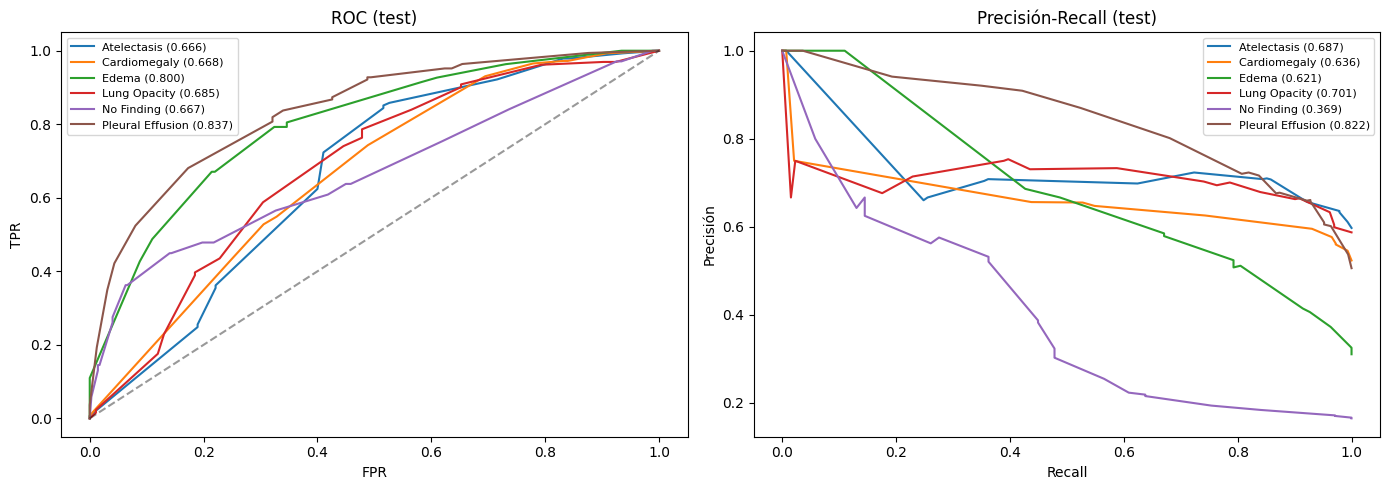

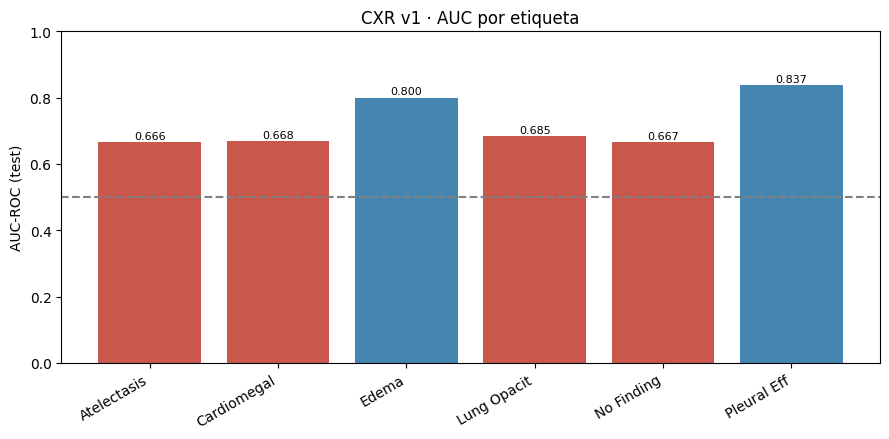

In [11]:
# CELDA 11 · CURVAS ROC / PR + AUC por etiqueta
fig,axes=plt.subplots(1,2,figsize=(14,5))
for j,l in enumerate(LABELS):
    s=m_test[:,j]==1; yt=y_test[s,j]; yp=test_pred[s,j]
    if len(np.unique(yt))<2: continue
    fpr,tpr,_=roc_curve(yt,yp); axes[0].plot(fpr,tpr,label=f"{l} ({M[l]['AUC']:.3f})")
    pr,rc,_=precision_recall_curve(yt,yp); axes[1].plot(rc,pr,label=f"{l} ({M[l]['AP']:.3f})")
axes[0].plot([0,1],[0,1],"k--",alpha=0.4); axes[0].set_title("ROC (test)"); axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR"); axes[0].legend(fontsize=8)
axes[1].set_title("Precisión-Recall (test)"); axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precisión"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIG_DIR/"roc_pr_v1.png",dpi=150,bbox_inches="tight"); plt.show()
fig2,ax=plt.subplots(figsize=(9,4.5)); aucs=[M[l]["AUC"] for l in LABELS]
ax.bar(range(N_LABELS),[0 if np.isnan(a) else a for a in aucs],
       color=["#c0392b" if (np.isnan(a) or a<0.7) else "#2471a3" for a in aucs],alpha=0.85)
ax.axhline(0.5,color="gray",ls="--"); ax.set_xticks(range(N_LABELS)); ax.set_xticklabels([l[:11] for l in LABELS],rotation=30,ha="right")
ax.set_ylim(0,1); ax.set_ylabel("AUC-ROC (test)"); ax.set_title("CXR v1 · AUC por etiqueta")
for i,a in enumerate(aucs):
    if not np.isnan(a): ax.text(i,a+0.01,f"{a:.3f}",ha="center",fontsize=8)
plt.tight_layout(); plt.savefig(FIG_DIR/"auc_por_etiqueta_v1.png",dpi=150,bbox_inches="tight"); plt.show()

In [12]:
# CELDA 12 · EXPORTAR OOF/val/test PARA EL STACKING (formato común: hadm_id, cxr_<label>, cxr_<label>_cal)
def save_predictions(df, raw, cal, name):
    cols={"hadm_id":df["hadm_id"].to_numpy()}
    for j,l in enumerate(LABELS):
        key=l.replace(" ","_"); cols[f"cxr_{key}"]=raw[:,j]; cols[f"cxr_{key}_cal"]=cal[:,j]
    out=pd.DataFrame(cols); p=OUTPUT_DIR/f"cxr_pred_{name}.csv"; out.to_csv(p,index=False)
    print(f"   guardado {p}  ({out.shape[0]} filas, {out.shape[1]} cols)")
save_predictions(df_train, oof_train,     oof_cal,   "oof_train")
save_predictions(df_val,   val_pred_raw,  val_pred,  "val")
save_predictions(df_test,  test_pred_raw, test_pred, "test")
print("OOF/val/test del CXR v1 exportados.")

   guardado outputs_cxr_densenet121_v1\cxr_pred_oof_train.csv  (10000 filas, 13 cols)
   guardado outputs_cxr_densenet121_v1\cxr_pred_val.csv  (750 filas, 13 cols)
   guardado outputs_cxr_densenet121_v1\cxr_pred_test.csv  (464 filas, 13 cols)
OOF/val/test del CXR v1 exportados.


---
## ✅ Resumen — CXR v1 (ligero)
Cabeza **LogReg one-vs-rest** sobre los **embeddings congelados** del DenseNet121 (reutilizados del v2). Mantiene masking,
negativos derivados, balanceo, calibración isotónica y **OOF sin fuga**. Es la línea base **más rápida** (minutos);
para exprimir el AUC, ver **v2 (óptimo)** y **v3 (pesado)**.